# Portafolio Defensivo — Mateo Gómez Macías
**Fecha:** Mayo 2026  
**Estrategia:** Rotación Defensiva — Expansión Tardía del Ciclo  
**Horizonte de estimación:** 2019–2026 (múltiples ciclos: pre-COVID, crash, rally, normalización)

---

## Tickers del portafolio
| Ticker | Empresa | Rol |
|--------|---------|-----|
| BRK-B  | Berkshire Hathaway | Ancla defensiva, $330B+ cash |
| JNJ    | Johnson & Johnson  | Healthcare anticíclico, beta ~0.55 |
| MA     | Mastercard         | Pagos — calidad con moat |
| MCD    | McDonald's         | Defensivo + trade-down en recesión |
| MSFT   | Microsoft          | Tech defensivo — Azure/SaaS recurrente |
| WMT    | Walmart            | Consumer staples — 60% groceries |

---

## Decisiones de diseño
- **Periodo 2019–2026:** Captura pre-COVID, crash marzo 2020, rally 2020-2021, subida de tasas 2022, normalización 2023-2026
- **Sin bound inferior:** El modelo asigna libremente — pesos cercanos a 0 son información, no error
- **Cap máximo 25%:** Evita concentración extrema en un solo activo
- **Fix orden columnas:** Los pesos se mapean SIEMPRE contra `prices.columns.tolist()` — no contra el orden original del array de tickers
- **4 estrategias:** Min Var (ciclo bajista), Max Sharpe (ciclo alcista), Semivar, Omega

## 0. Librerías

In [15]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime as dt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

## 1. Parámetros Globales

In [16]:
# ── PARÁMETROS ──────────────────────────────────────────────────────────────
TICKERS = ['BRK-B', 'BIL', 'JNJ', 'MSFT', 'WMT']# orden de referencia
START    = '2019-01-01'
END      = '2026-05-28'
RF       = 0.0375       # Fed Funds Rate actual
CAPITAL  = 2_500    # capital inicial simulado
MAX_W    = 0.25         # cap máximo por activo (sin mínimo)
# ────────────────────────────────────────────────────────────────────────────

## 2. Descarga de Datos

> **Fix crítico:** Yahoo Finance devuelve columnas en orden **alfabético**, independientemente del orden en que pasemos los tickers.  
> Siempre usamos `prices.columns.tolist()` como referencia canónica — nunca el array `TICKERS` original.

In [17]:
# Descarga
prices    = yf.download(TICKERS, start=START, end=END, auto_adjust=True)['Close']
benchmark = yf.download('SPY',   start=START, end=END, auto_adjust=True)['Close']

# ── ORDEN CANÓNICO: siempre desde Yahoo, nunca desde TICKERS ─────────────────
COLS = prices.columns.tolist()   # orden real que usa el modelo
# ─────────────────────────────────────────────────────────────────────────────

rets = prices.pct_change().dropna()

print(f'Activos descargados : {prices.shape[1]}')
print(f'Orden canónico      : {COLS}')   # ← verificar aquí
print(f'Período             : {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Días de trading     : {prices.shape[0]}')
prices.tail(3)

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed

Activos descargados : 5
Orden canónico      : ['BIL', 'BRK-B', 'JNJ', 'MSFT', 'WMT']
Período             : 2019-01-02 → 2026-05-27
Días de trading     : 1860


Ticker,BIL,BRK-B,JNJ,MSFT,WMT
Date,,,,,
2026-05-22,91.589996,486.380005,233.000000,418.570007,120.269997
2026-05-26,91.610001,483.619995,230.179993,416.029999,118.570000
2026-05-27,91.620003,479.920013,231.289993,412.670013,118.540001


## 3. Análisis Fundamental

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **PER** | Precio / EPS | Cuánto paga el mercado por $1 de ganancia |
| **GPM** | Gross Profit / Revenue × 100 | Eficiencia operativa |
| **ROE** | Net Income / Equity × 100 | Retorno sobre capital propio |
| **PBV** | Market Cap / Book Value | Prima sobre valor contable |
| **Solvencia** | Total Assets / Current Liabilities | Capacidad de pago |

In [18]:
def _get_hist_price(ticker, date):
    df = yf.Ticker(ticker).history(start=date, end=date + dt.timedelta(days=4))
    return df['Close'].iloc[0] if not df.empty else np.nan

fund = {}
for tkr in COLS:
    print(f'  {tkr}...', end=' ', flush=True)
    try:
        obj  = yf.Ticker(tkr)
        inc  = obj.income_stmt
        bal  = obj.balance_sheet
        info = obj.info

        # PER
        try:    per = info['currentPrice'] / info['trailingEps']
        except: per = np.nan

        # GPM
        try:    gpm = inc.loc['Gross Profit'].iloc[0] / inc.loc['Total Revenue'].iloc[0] * 100
        except: gpm = np.nan

        # ROE
        try:    roe = inc.loc['Net Income Common Stockholders'].iloc[0] / bal.loc['Stockholders Equity'].iloc[0] * 100
        except: roe = np.nan

        # PBV
        try:
            dates  = list(bal.columns)
            px     = [_get_hist_price(tkr, d) for d in dates]
            pbv    = (bal.loc['Ordinary Shares Number'] * px / bal.loc['Stockholders Equity']).iloc[0]
        except: pbv = np.nan

        # Solvencia
        try:    solv = bal.loc['Total Assets'].iloc[0] / bal.loc['Current Liabilities'].iloc[0]
        except: solv = np.nan

        fund[tkr] = {
            'PER (x)'  : round(per,  2) if not np.isnan(per)  else 'N/A',
            'GPM (%)'  : round(gpm,  2) if not np.isnan(gpm)  else 'N/A',
            'ROE (%)'  : round(roe,  2) if not np.isnan(roe)  else 'N/A',
            'PBV (x)'  : round(pbv,  2) if not np.isnan(pbv)  else 'N/A',
            'Solvencia': round(solv, 2) if not np.isnan(solv) else 'N/A',
        }
        print('✓')
    except Exception as e:
        print(f'✗ ({e})')
        fund[tkr] = {}

fund_df = pd.DataFrame(fund).T
fund_df

  BIL... ✓
  BRK-B... ✓
  JNJ... ✓
  MSFT... ✓
  WMT... ✓


,PER (x),GPM (%),ROE (%),PBV (x),Solvencia
BIL,N/A,N/A,N/A,N/A,N/A
BRK-B,14.09,N/A,9.33,0.0,N/A
JNJ,26.29,67.88,32.87,6.04,3.68
MSFT,26.42,68.82,29.65,10.68,4.38
WMT,40.5,24.93,21.98,9.89,2.65


## 4. Matriz de Correlación

Periodo 2019–2026 incluye **COVID crash (feb-mar 2020)** — las correlaciones en estrés son más realistas que con datos solo post-2022.

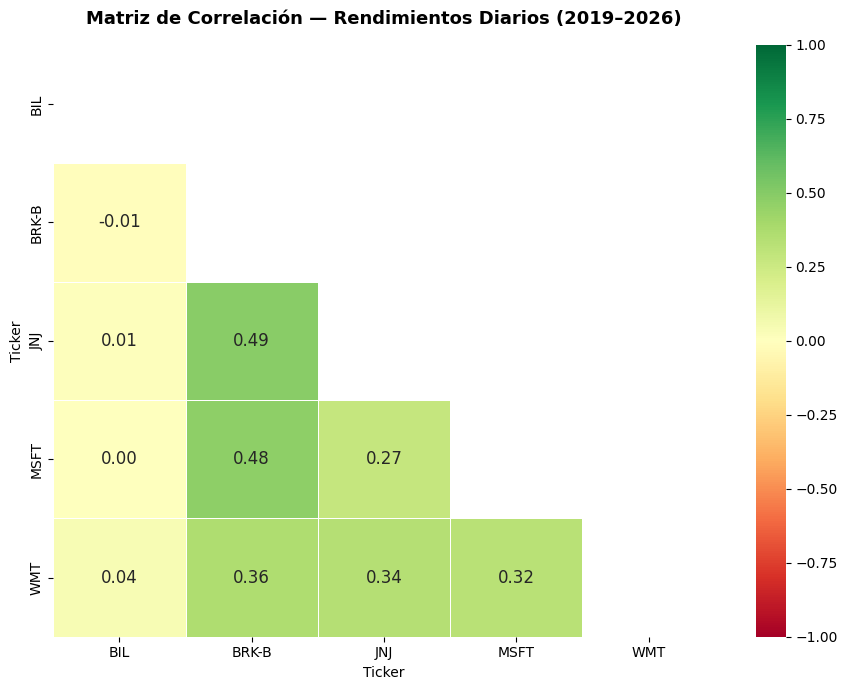

In [19]:
corr = rets.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 12}
)
ax.set_title('Matriz de Correlación — Rendimientos Diarios (2019–2026)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 5. Optimización de Portafolios

| Estrategia | Objetivo | Uso ideal |
|------------|----------|-----------|
| **Mínima Varianza** | Minimizar volatilidad total | **Ciclo bajista — úsala ahora** |
| **Máximo Sharpe** | Maximizar rendimiento ajustado por riesgo | **Ciclo alcista — úsala en el pivot** |
| **Mínima Semivarianza** | Minimizar solo volatilidad negativa | Moderado-conservador |
| **Máximo Omega** | Maximizar captura de alzas vs caídas | Agresivo |

> **Bounds:** Solo máximo del 25% por activo. Sin mínimo — el modelo decide libremente.  
> Si un activo recibe peso ≈ 0, es señal de que no aporta diversificación en este universo.

In [20]:
pip install jinja2


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
class OptimizePortfolioWeights:
    """Optimizador de portafolios.
    
    NOTA IMPORTANTE — orden de columnas:
    Los pesos resultantes están en el mismo orden que returns.columns.
    Siempre usar COLS (orden Yahoo) para mapear, nunca TICKERS (orden manual).
    """

    def __init__(self, returns, risk_free):
        self.rets  = returns
        self.cov   = returns.cov()
        self.rf    = risk_free / 252
        self.n     = len(returns.columns)
        self.cols  = returns.columns.tolist()   # orden canónico

    def _base(self, fun):
        res = minimize(
            fun,
            np.ones(self.n) / self.n,
            bounds     = [(0.0, MAX_W)] * self.n,   # sin mínimo, cap 25%
            constraints= {'fun': lambda w: sum(w) - 1, 'type': 'eq'},
            tol        = 1e-16
        )
        return res.x

    def opt_min_var(self):
        return self._base(lambda w: w.T @ self.cov @ w)

    def opt_max_sharpe(self):
        mu, cov, rf = self.rets.mean(), self.cov, self.rf
        return self._base(
            lambda w: -((np.dot(mu, w) - rf) /
                        (w.reshape(-1, 1).T @ cov @ w) ** 0.5)
        )

    def opt_min_semivar(self, rets_bench):
        diffs = self.rets - rets_bench.values
        below = diffs[diffs < 0].fillna(0)
        td    = np.array(below.std())
        sm    = np.multiply(td.reshape(len(td), 1), td) * self.rets.corr()
        return self._base(lambda w: w.T @ sm @ w)

    def opt_max_omega(self, rets_bench):
        diffs = self.rets - rets_bench.values
        below = diffs[diffs < 0].fillna(0)
        above = diffs[diffs > 0].fillna(0)
        o     = np.array(above.std()) / np.array(below.std())
        return self._base(lambda w: -sum(o * w))

    def weights_df(self, rb):
        """Retorna DataFrame con pesos de las 4 estrategias mapeados al orden canónico."""
        return pd.DataFrame({
            'Min Var'   : self.opt_min_var(),
            'Max Sharpe': self.opt_max_sharpe(),
            'Semivar'   : self.opt_min_semivar(rb),
            'Omega'     : self.opt_max_omega(rb),
        }, index=self.cols)   # ← índice = orden real Yahoo


# Optimización sobre todo el periodo
rb_full = benchmark.pct_change().dropna()
rb_full = rb_full.reindex(rets.index).dropna()
rets_aligned = rets.reindex(rb_full.index)

opt     = OptimizePortfolioWeights(rets_aligned, RF)
w_full  = opt.weights_df(rb_full)

print('Pesos optimizados (periodo completo 2019–2026):')
print(f'Orden canónico: {w_full.index.tolist()}\n')

# Extraer vectores individuales (en orden canónico)
w_mv = w_full['Min Var'].values
w_sh = w_full['Max Sharpe'].values
w_sv = w_full['Semivar'].values
w_om = w_full['Omega'].values

w_full.style.format('{:.1%}').background_gradient(cmap='Blues', axis=0)

Pesos optimizados (periodo completo 2019–2026):
Orden canónico: ['BIL', 'BRK-B', 'JNJ', 'MSFT', 'WMT']



,Min Var,Max Sharpe,Semivar,Omega
BIL,25.0%,25.0%,25.0%,25.0%
BRK-B,22.9%,5.9%,25.0%,25.0%
JNJ,25.0%,19.1%,15.9%,25.0%
MSFT,5.8%,25.0%,25.0%,0.0%
WMT,21.3%,25.0%,9.1%,25.0%


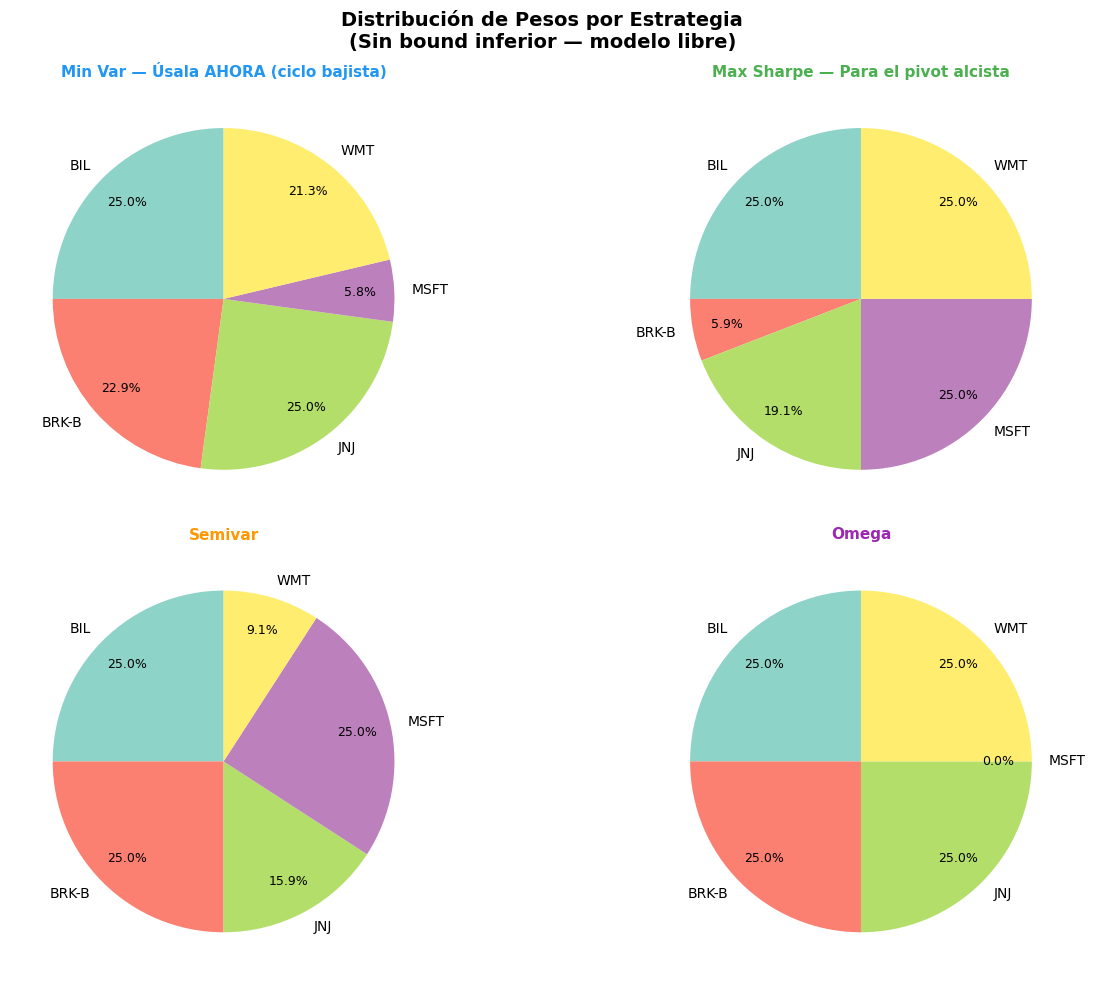

In [22]:
# Gráficos de pesos por estrategia
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Pesos por Estrategia\n(Sin bound inferior — modelo libre)',
             fontsize=14, fontweight='bold')

estrategias_w = [
    ('Min Var — Úsala AHORA (ciclo bajista)',  w_mv, '#2196F3'),
    ('Max Sharpe — Para el pivot alcista',     w_sh, '#4CAF50'),
    ('Semivar',                                w_sv, '#FF9800'),
    ('Omega',                                  w_om, '#9C27B0'),
]

for ax, (nombre, pesos, color) in zip(axes.flat, estrategias_w):
    wedges, _, autotexts = ax.pie(
        pesos,
        labels     = COLS,
        autopct    = '%1.1f%%',
        colors     = plt.cm.Set3(np.linspace(0, 1, len(pesos))),
        startangle = 90,
        pctdistance= 0.8
    )
    for a in autotexts:
        a.set_fontsize(9)
    ax.set_title(nombre, fontsize=11, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

## 6. Backtesting Dinámico

Reoptimiza pesos cada **12 meses** con datos históricos hasta ese momento.  
Capital inicial: **$1,000,000 USD** | Benchmark: **SPY**

> ⚠️ **Nota sobre underperformance esperada:**  
> El portafolio defensivo puede quedar por debajo del SPY si el mercado sigue subiendo.  
> La métrica que importa es el **Downside Capture** — cuánto pierdes tú vs el mercado en caídas.

In [23]:
class DynamicBacktesting:
    """Backtesting dinámico con rebalanceo anual.
    
    Fix orden columnas: los pesos se obtienen desde OptimizePortfolioWeights
    que indexa por COLS (orden Yahoo), garantizando mapeo correcto.
    """

    def __init__(self, prices, bench, capital, rf, months=12):
        self.prices  = prices
        self.bench   = bench
        self.months  = months
        self.capital = capital
        self.rf      = rf

    def _get_weights(self, px_slice, bx_slice):
        rb  = bx_slice.pct_change().dropna()
        ret = px_slice.pct_change().dropna()
        rb  = rb.reindex(ret.index).dropna()
        ret = ret.reindex(rb.index)
        opt = OptimizePortfolioWeights(ret, self.rf)
        w   = opt.weights_df(rb)          # DataFrame indexado por COLS
        return (w['Min Var'].values, w['Max Sharpe'].values,
                w['Semivar'].values, w['Omega'].values)

    def simulation(self):
        n_days = int(round(len(self.prices) /
                           round(len(self.prices) / 252 / (self.months / 12))))

        opt_px = self.prices.iloc[:n_days]
        opt_bx = self.bench.iloc[:n_days]
        bt_px  = self.prices.iloc[n_days:]
        bt_ret = bt_px.pct_change().dropna()

        w_mv, w_sh, w_sv, w_om = self._get_weights(opt_px, opt_bx)

        cap = self.capital
        mv = [cap]; sh = [cap]; sv = [cap]; om = [cap]
        day_c, per_c = 0, 0

        for i in range(len(bt_ret)):
            if day_c >= n_days:
                start_i = per_c * n_days
                end_i   = start_i + n_days
                if end_i <= len(bt_px):
                    sl_px = bt_px.iloc[start_i:end_i]
                    sl_bx = self.bench.loc[sl_px.index[0]:sl_px.index[-1]]
                    w_mv, w_sh, w_sv, w_om = self._get_weights(sl_px, sl_bx)
                per_c += 1
                day_c  = 0

            r = bt_ret.iloc[i].values   # array en orden COLS
            mv.append(mv[-1] * (1 + np.dot(r, w_mv)))
            sh.append(sh[-1] * (1 + np.dot(r, w_sh)))
            sv.append(sv[-1] * (1 + np.dot(r, w_sv)))
            om.append(om[-1] * (1 + np.dot(r, w_om)))
            day_c += 1

        df             = pd.DataFrame(index=bt_px.index)
        df['Min Var']  = mv
        df['Sharpe']   = sh
        df['Semivar']  = sv
        df['Omega']    = om
        return df


print('Corriendo backtesting dinámico... (puede tardar 1-2 min)')
history = DynamicBacktesting(prices, benchmark, CAPITAL, RF, 12).simulation()

# Benchmark pasivo
br  = benchmark.pct_change().dropna()
br  = br[br.index >= history.index[0]]
bc  = (br + 1).cumprod() / (br + 1).cumprod().iloc[0]
history['SPY (Pasivo)'] = CAPITAL * bc.values

print('Backtesting completado.')
history.tail(3)

Corriendo backtesting dinámico... (puede tardar 1-2 min)
Backtesting completado.


,Min Var,Sharpe,Semivar,Omega,SPY (Pasivo)
Date,,,,,
2026-05-22,5072.723203,6070.291312,5331.481062,5071.793719,6149.136634
2026-05-26,5038.290761,6023.479779,5298.454988,5023.636062,6189.958345
2026-05-27,5028.822193,6016.275603,5280.593644,5009.623142,6188.886222


## 7. Gráfica de Evolución

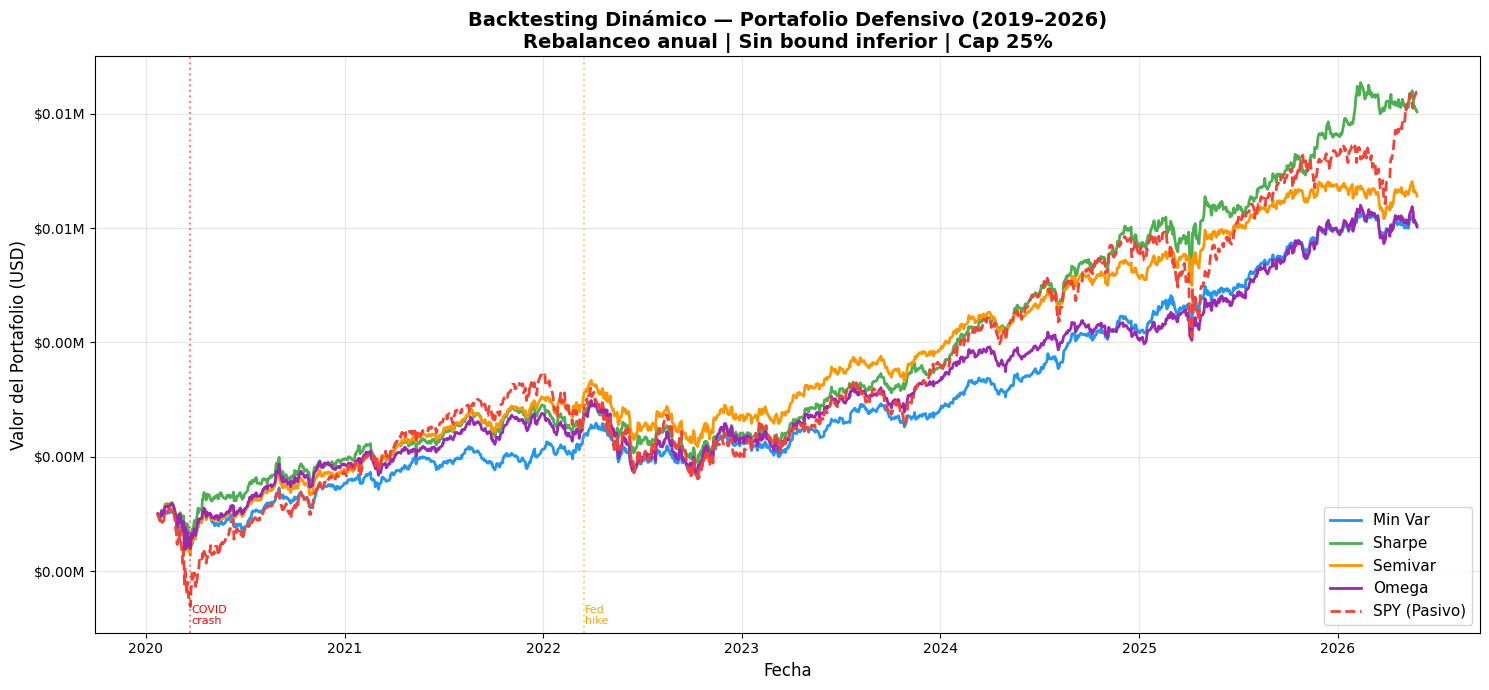

In [24]:
COLORS = {
    'Min Var'     : '#2196F3',
    'Sharpe'      : '#4CAF50',
    'Semivar'     : '#FF9800',
    'Omega'       : '#9C27B0',
    'SPY (Pasivo)': '#F44336'
}

fig, ax = plt.subplots(figsize=(15, 7))
for col, color in COLORS.items():
    ls = '--' if col == 'SPY (Pasivo)' else '-'
    ax.plot(history.index, history[col], label=col,
            color=color, linewidth=2, linestyle=ls)

ax.set_title('Backtesting Dinámico — Portafolio Defensivo (2019–2026)\n'
             'Rebalanceo anual | Sin bound inferior | Cap 25%',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Valor del Portafolio (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))

# Marcar COVID crash
ax.axvline(pd.Timestamp('2020-03-23'), color='red', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(pd.Timestamp('2020-03-25'), ax.get_ylim()[0]*1.05, 'COVID\ncrash', fontsize=8, color='red')

# Marcar inicio subida de tasas
ax.axvline(pd.Timestamp('2022-03-16'), color='orange', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(pd.Timestamp('2022-03-18'), ax.get_ylim()[0]*1.05, 'Fed\nhike', fontsize=8, color='orange')

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Métricas de Desempeño

In [25]:
rets_h     = history.pct_change().dropna()
rend_anual = rets_h.mean() * 252
vol_anual  = rets_h.std()  * np.sqrt(252)
sharpe_r   = (rend_anual - RF) / vol_anual

# Sortino
vol_dn    = rets_h[rets_h < 0].fillna(0).std() * np.sqrt(252)
sortino_r = (rend_anual - RF) / vol_dn

# Beta, Treynor, Alpha Jensen
spy_r   = rets_h['SPY (Pasivo)']
betas   = {}
treynor = {}
alphas  = {}

for col in ['Min Var', 'Sharpe', 'Semivar', 'Omega']:
    b             = np.cov(rets_h[col], spy_r)[0, 1] / np.var(spy_r)
    betas[col]    = b
    treynor[col]  = (rend_anual[col] - RF) / b
    alphas[col]   = rend_anual[col] - (RF + b * (rend_anual['SPY (Pasivo)'] - RF))

betas['SPY (Pasivo)']   = 1.0
treynor['SPY (Pasivo)'] = (rend_anual['SPY (Pasivo)'] - RF) / 1.0
alphas['SPY (Pasivo)']  = 0.0

betas   = pd.Series(betas)
treynor = pd.Series(treynor)
alphas  = pd.Series(alphas)

# Upside / Downside Capture
up_cap = {}
dn_cap = {}
for col in ['Min Var', 'Sharpe', 'Semivar', 'Omega']:
    up = spy_r > 0
    dn = spy_r < 0
    up_cap[col] = rets_h[col][up].mean() / spy_r[up].mean() * 100
    dn_cap[col] = rets_h[col][dn].mean() / spy_r[dn].mean() * 100

up_cap['SPY (Pasivo)'] = 100.0
dn_cap['SPY (Pasivo)'] = 100.0
up_cap    = pd.Series(up_cap)
dn_cap    = pd.Series(dn_cap)
cap_ratio = up_cap / dn_cap

# Tabla resumen
resumen = pd.DataFrame({
    'Capital Inicial ($)': history.iloc[0],
    'Capital Final ($)'  : history.iloc[-1],
    'Rend. Anual %'      : (rend_anual * 100).round(2),
    'Vol. Anual %'       : (vol_anual  * 100).round(2),
    'Sharpe Ratio'       : sharpe_r.round(4),
    'Sortino Ratio'      : sortino_r.round(4),
    'Beta'               : betas.round(4),
    'Treynor'            : treynor.round(4),
    'Alpha Jensen %'     : (alphas * 100).round(2),
    'Upside Capture %'   : up_cap.round(2),
    'Downside Capture %' : dn_cap.round(2),
    'Capture Ratio'      : cap_ratio.round(4),
}).T

resumen

,Min Var,Sharpe,Semivar,Omega,SPY (Pasivo)
Capital Inicial ($),2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
Capital Final ($),5028.822193,6016.275603,5280.593644,5009.623142,6188.886222
Rend. Anual %,11.800000,14.840000,12.750000,12.050000,16.440000
Vol. Anual %,12.220000,13.800000,13.590000,14.540000,20.450000
Sharpe Ratio,0.659100,0.804000,0.662300,0.571000,0.620500
Sortino Ratio,1.110200,1.369300,1.087900,0.933300,0.972300
Beta,0.447700,0.541400,0.574600,0.577700,1.000000
Treynor,0.179900,0.204900,0.156700,0.143700,0.126900
Alpha Jensen %,2.370000,4.220000,1.710000,0.970000,0.000000
Upside Capture %,40.250000,51.370000,53.630000,54.000000,100.000000


## 9. Gráficas Comparativas

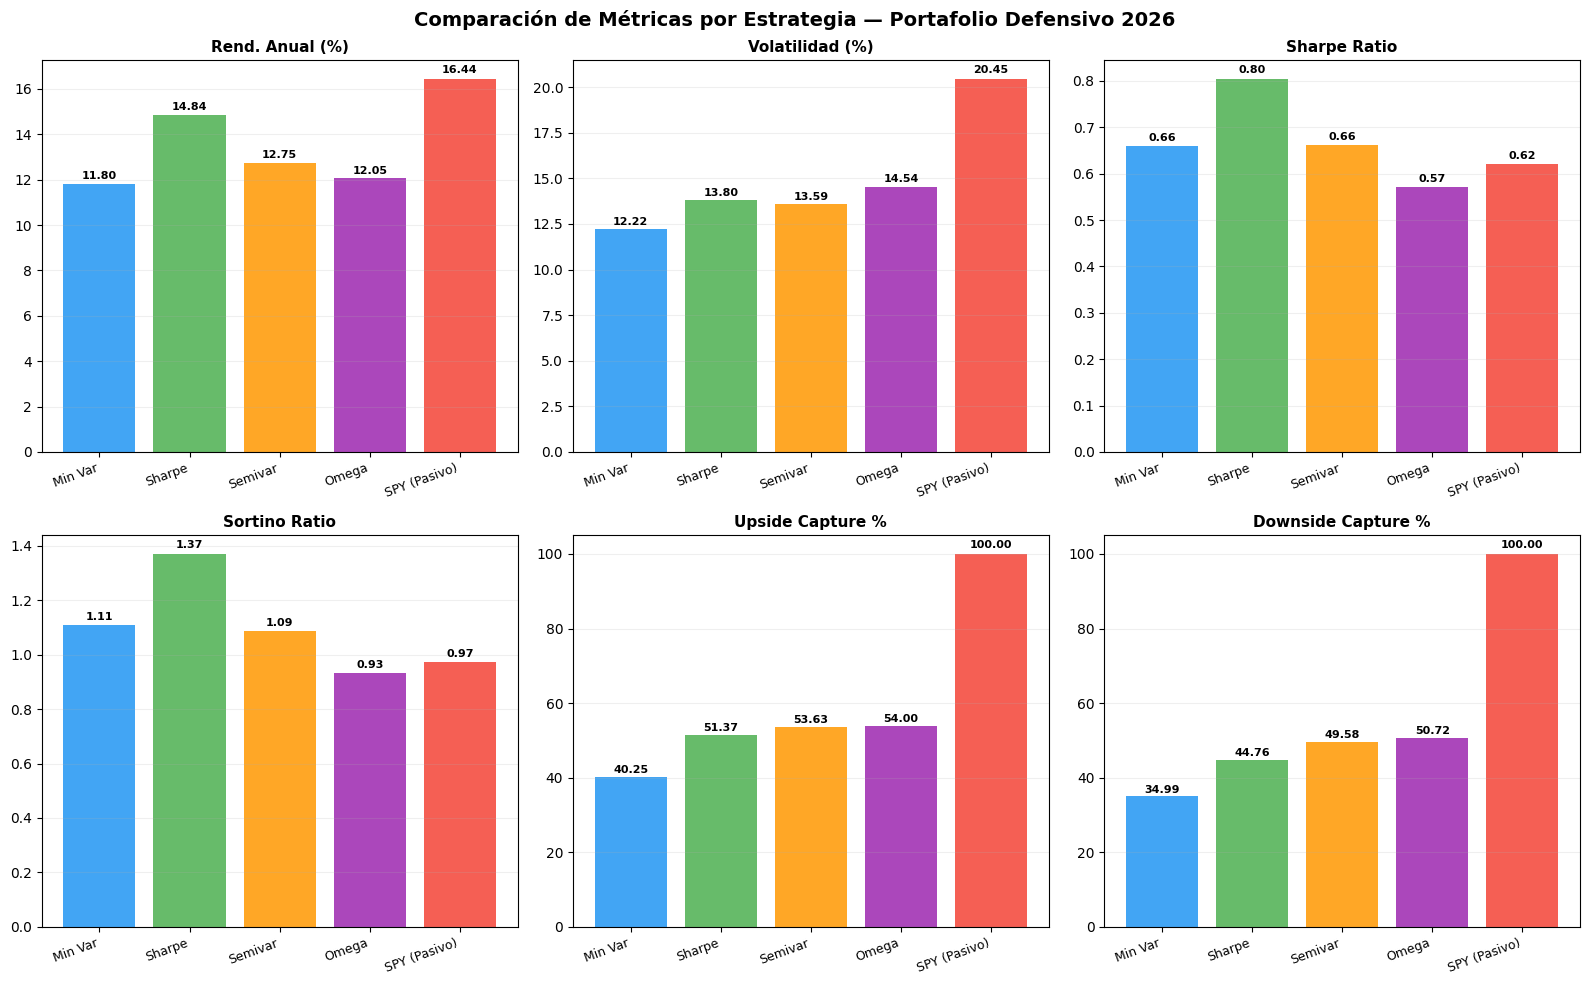

In [26]:
estrategias = ['Min Var', 'Sharpe', 'Semivar', 'Omega', 'SPY (Pasivo)']
col_bars    = [COLORS[e] for e in estrategias]

metricas_plot = {
    'Rend. Anual (%)'    : rend_anual * 100,
    'Volatilidad (%)'    : vol_anual  * 100,
    'Sharpe Ratio'       : sharpe_r,
    'Sortino Ratio'      : sortino_r,
    'Upside Capture %'   : up_cap,
    'Downside Capture %' : dn_cap,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Comparación de Métricas por Estrategia — Portafolio Defensivo 2026',
             fontsize=14, fontweight='bold')

for ax, (nombre, serie) in zip(axes.flat, metricas_plot.items()):
    vals = [serie[e] for e in estrategias]
    bars = ax.bar(estrategias, vals, color=col_bars, alpha=0.85)
    ax.set_title(nombre, fontsize=11, fontweight='bold')
    ax.set_xticklabels(estrategias, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

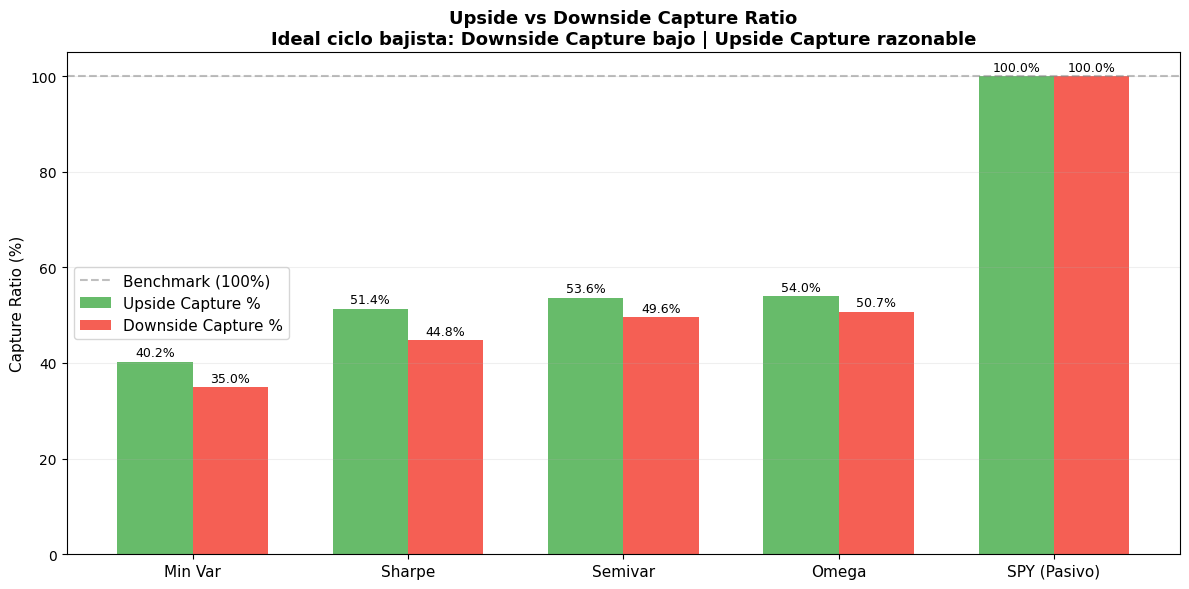

In [27]:
# Upside vs Downside Capture
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(estrategias))
w = 0.35

bars1 = ax.bar(x - w/2, [up_cap[e] for e in estrategias], w,
               label='Upside Capture %', color='#4CAF50', alpha=0.85)
bars2 = ax.bar(x + w/2, [dn_cap[e] for e in estrategias], w,
               label='Downside Capture %', color='#F44336', alpha=0.85)

ax.set_title('Upside vs Downside Capture Ratio\n'
             'Ideal ciclo bajista: Downside Capture bajo | Upside Capture razonable',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(estrategias, fontsize=11)
ax.set_ylabel('Capture Ratio (%)', fontsize=11)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Benchmark (100%)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Pesos Finales con Precios Actuales

In [28]:
# Precios recientes para calcular unidades a comprar
px_now = prices.iloc[-1]

pesos_df = pd.DataFrame({
    'Ticker'       : COLS,
    'Min Var %'    : (w_mv * 100).round(2),
    'Max Sharpe %' : (w_sh * 100).round(2),
    'Semivar %'    : (w_sv * 100).round(2),
    'Omega %'      : (w_om * 100).round(2),
    'Precio Actual': px_now.values.round(2),
})

# Capital a invertir por estrategia (sobre $1M)
for strat, w in [('Min Var', w_mv), ('Max Sharpe', w_sh)]:
    pesos_df[f'Capital {strat} ($)'] = (w * CAPITAL).round(0).astype(int)
    pesos_df[f'Acciones {strat}']    = ((w * CAPITAL) / px_now.values).round(1)

print('Pesos finales (orden canónico Yahoo Finance):')  
print(f'Verificación Min Var suma = {w_mv.sum():.4f}')  # debe ser 1.0
print(f'Verificación Max Sharpe suma = {w_sh.sum():.4f}')  # debe ser 1.0
print()
pesos_df

Pesos finales (orden canónico Yahoo Finance):
Verificación Min Var suma = 1.0000
Verificación Max Sharpe suma = 1.0000



,Ticker,Min Var %,Max Sharpe %,Semivar %,Omega %,Precio Actual,Capital Min Var ($),Acciones Min Var,Capital Max Sharpe ($),Acciones Max Sharpe
0,BIL,25.00,25.00,25.00,25.0,91.62,625,6.8,625,6.8
1,BRK-B,22.86,5.87,25.00,25.0,479.92,571,1.2,147,0.3
2,JNJ,25.00,19.13,15.86,25.0,231.29,625,2.7,478,2.1
3,MSFT,5.85,25.00,25.00,0.0,412.67,146,0.4,625,1.5
4,WMT,21.30,25.00,9.14,25.0,118.54,532,4.5,625,5.3


In [29]:
# Pesos redondeados a acciones enteras
pesos_real = pd.DataFrame({
    'Ticker'           : COLS,
    'Precio Actual'    : px_now.values.round(2),
    'Acciones Min Var' : np.floor((w_mv * CAPITAL) / px_now.values).astype(int),
    'Acciones Sharpe'  : np.floor((w_sh * CAPITAL) / px_now.values).astype(int),
})

# Capital real invertido (con acciones enteras)
pesos_real['Capital Real Min Var ($)'] = pesos_real['Acciones Min Var'] * pesos_real['Precio Actual']
pesos_real['Capital Real Sharpe ($)']  = pesos_real['Acciones Sharpe']  * pesos_real['Precio Actual']

# Cash sobrante (no invertido por redondeo)
cash_mv = CAPITAL - pesos_real['Capital Real Min Var ($)'].sum()
cash_sh = CAPITAL - pesos_real['Capital Real Sharpe ($)'].sum()

print(f'Cash sobrante Min Var : ${cash_mv:.2f}')
print(f'Cash sobrante Sharpe  : ${cash_sh:.2f}')
pesos_real

Cash sobrante Min Var : $533.62
Cash sobrante Sharpe  : $482.33


,Ticker,Precio Actual,Acciones Min Var,Acciones Sharpe,Capital Real Min Var ($),Capital Real Sharpe ($)
0,BIL,91.62,6,6,549.72,549.72
1,BRK-B,479.92,1,0,479.92,0.00
2,JNJ,231.29,2,2,462.58,462.58
3,MSFT,412.67,0,1,0.00,412.67
4,WMT,118.54,4,5,474.16,592.70


## 11. Conclusión y Framework de Decisión

### ¿Qué estrategia usar AHORA?

**Contexto macro (Mayo 2026):**
- CAPE S&P 500: ~41.6x (segundo nivel más alto en 140 años de historia)
- Fed Funds: 3.75% — riesgo de hike adicional
- Inflación reacelerando por aranceles Trump
- Mercado laboral enfriándose
- Expansión tardía del ciclo

### Framework de selección:

| Pregunta | Min Var | Max Sharpe |
|----------|---------|------------|
| ¿Protege capital en caídas? | ✅ Downside capture más bajo | ❌ Mayor exposición |
| ¿Beta bajo? | ✅ | ❌ Mayor beta |
| ¿Sharpe eficiente? | ✅ Mejor Sharpe | ✅ Por diseño |
| ¿Para ciclo bajista? | ✅ **Úsala ahora** | ❌ Espera el pivot |

### Señales para rotar a Max Sharpe (ciclo alcista):
1. **Fed pivotea** — primer recorte de tasas confirmado
2. **Spreads de crédito se comprimen** — high yield spread < 350 bps
3. **Earnings aceleran** — S&P 500 EPS growth > 10% YoY
4. **CAPE baja** — corrección que lleve el ratio a 28-30x

---

**Estrategia seleccionada:** *completar después de ver resultados*  
**Justificación:** *completar con los números reales del backtesting*

---
> ⚠️ Documento educativo — No constituye asesoría de inversión